
# Embedding sampling, TSNE and clustering of skills learned from Atari Crowdplay dataset




In [15]:

import matplotlib.pyplot as plt
import gym
from gym.wrappers import AtariPreprocessing

from VAE.atari.skill_vae_with_learnt_prior.utils import load_ae_model
import torch
import tqdm 
import pandas
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from VAE.atari.skill_vae_with_learnt_prior.configs import config
from VAE.atari.skill_vae_with_learnt_prior.env_wrapper import get_dataset, get_trajectory
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
sns.set()

In [ ]:
#! pip install numpy==1.23.1

## Data generation


In [6]:


def play_policy(env, model, num_eval=100, traj_length=10, tanh=True):
    model.eval()
    rewards = []
    latents = []
    data = []
    # for i in range(num_eval):
    for i in tqdm.tqdm(range(num_eval)):
        state = env.reset()
        state = torch.FloatTensor(state[0]).unsqueeze(0).unsqueeze(0)
        latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        latents.append(latent[0])
        d = {"latent": latent[0]}
        done = False
        reward = 0
        num_steps = 0
        actions = []
        while not done:
            # latents.append(latent[0])
            if tanh:
                latent = torch.tanh(latent)
            for t in range(traj_length):
                action, _ = model.decoder.act(latent, state, encode_state=True)
                action = action.cpu().numpy().flatten()[0]
                actions.append(action)
                s, r, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                reward += r
                num_steps += 1
                state = torch.FloatTensor(s).unsqueeze(0).unsqueeze(0)
                latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        actions_freq = {f"action_{i}":actions.count(i)/len(actions) for i in set(actions)}

        d.update(actions_freq)
        data.append(d)
        rewards.append(reward)
    print(np.mean(rewards))
    return rewards, latents, data

In [7]:
# collect skill embeddings by playing the game using the prior and the decoder

env = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env = AtariPreprocessing(env)
model = load_ae_model(env,
                      "/VAE/atari/skill_vae_with_learnt_prior/models/human_ai_383_dataset_model_latent_size_2_traj_len_28/atari-600.pt")
rewards, skill_embeddings, data = play_policy(env, model, traj_length=28)

X = np.array(skill_embeddings)
df = pandas.DataFrame(data)
df = df.fillna(0)
df

  0%|          | 0/100 [00:00<?, ?it/s]/home/sara/.venv/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
100%|██████████| 100/100 [08:59<00:00,  5.39s/it]

185.55


,latent,action_0,action_1,action_2,action_3,action_4,action_5
0,"[tensor(0.0131), tensor(0.0079)]",0.251984,0.242063,0.200397,0.033730,0.226190,0.045635
1,"[tensor(-0.0014), tensor(-0.0111)]",0.178571,0.315789,0.174812,0.033835,0.212406,0.084586
2,"[tensor(-0.0070), tensor(0.0270)]",0.301587,0.315476,0.033730,0.039683,0.202381,0.107143
3,"[tensor(-0.0166), tensor(0.0062)]",0.226190,0.223214,0.190476,0.072917,0.206845,0.080357
4,"[tensor(0.0347), tensor(-0.0113)]",0.301843,0.217742,0.120968,0.056452,0.214286,0.088710
...,...,...,...,...,...,...,...
95,"[tensor(3.2726e-05), tensor(0.0078)]",0.140756,0.338235,0.069328,0.044118,0.325630,0.081933
96,"[tensor(-0.0034), tensor(0.0179)]",0.237637,0.281593,0.114011,0.074176,0.204670,0.087912
97,"[tensor(0.0121), tensor(0.0042)]",0.242188,0.308036,0.161830,0.073661,0.157366,0.056920
98,"[tensor(0.0105), tensor(0.0059)]",0.083333,0.422619,0.122024,0.026786,0.241071,0.104167


load datafile: 100%|██████████| 3/3 [00:17<00:00,  5.85s/it]


688856


<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

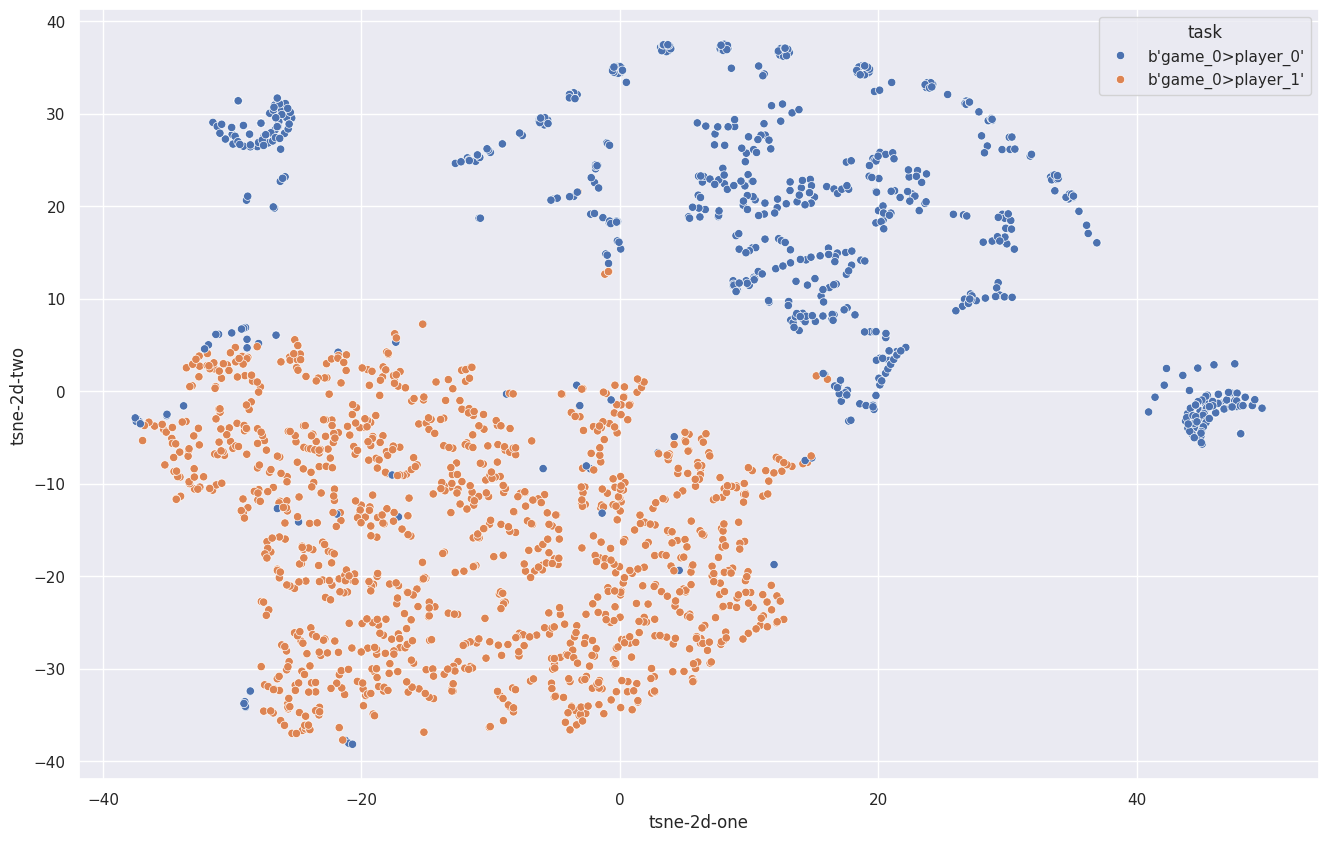

In [43]:

def one_hot(x, length):
    o = [0 for _ in range(length)]
    o[x] = 1
    return o

def data_for_episode(trajectory):
    actions = []
    for i in range(len(trajectory)):
        actions.append(one_hot(trajectory[i], 16))
    actions_frequency = {}
    for a in range(len(actions[0])):
        actions_frequency[f"action_{a}"] = sum([actions[i][a] for i in range(len(trajectory))])/len(trajectory)
    data = {}
    data.update(actions_frequency)
    return data

# here we plot the action frequency information of the trajectories in the dataset (trajectories are sequences of size H)
# we then map them to 2 dimensions using TSNE and plot them
traj_data = []
data = get_dataset("/home/sara/repositories/player_model_dt/VAE/atari/datasets/dataset_competitive_ai_human_383_episodes.hdf5")
state_traj, action_traj, task_traj = get_trajectory(config['env_name'], traj_len=28, dataset=data, random_start=False)
for traj, task in zip(action_traj[::10], task_traj[::10]):
    d = {'task': str(task[0])}
    d.update(data_for_episode(traj))
    traj_data.append(d)
    
df = pandas.DataFrame(traj_data)
df = df.fillna(0)

df_subset = df.drop('task', axis=1)
# tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne = TSNE(init='pca')
tsne_results = tsne.fit_transform(df_subset)
df_fig = df.copy()
df_fig['tsne-2d-one'] = tsne_results[:,0]
df_fig['tsne-2d-two'] = tsne_results[:,1]
plt.figure(figsize=(16,10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    # style="agent",
    hue="task",
    data=df_fig,
)

In [2]:
import itertools
def get_dataset_embeddings(model, dataset):
    embeddings, tasks = [], []
    obs = list(itertools.chain(dataset['observations'][:10000], dataset['observations'][-10000:]))
    task_list = list(itertools.chain(dataset['tasks'][:10000], dataset['tasks'][-10000:]))
    for state, task in tqdm.tqdm(zip(obs, task_list)):
        state = torch.FloatTensor(state[0]).unsqueeze(0).unsqueeze(0)
        latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        embeddings.append(latent[0])
        tasks.append(task)
    return embeddings, tasks

In [4]:
# running the dataset through the learned prior to get the corresponding skill embeddings
env = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env = AtariPreprocessing(env)
data = get_dataset("/home/sara/repositories/player_model_dt/VAE/atari/datasets/dataset_competitive_ai_human_383_episodes.hdf5")

model = load_ae_model(env,
                      "/VAE/atari/skill_vae_with_learnt_prior/models/human_ai_383_dataset_model_latent_size_2_traj_len_28/atari-600.pt")
embeddings, tasks = get_dataset_embeddings(model, data)
print(tasks[:10], tasks[-10:])

load datafile: 100%|██████████| 3/3 [00:15<00:00,  5.04s/it]
20000it [01:33, 213.03it/s]


[b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0', b'game_0>player_0'] [b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1', b'game_0>player_1']


<Axes: xlabel='latent-1', ylabel='latent-2'>

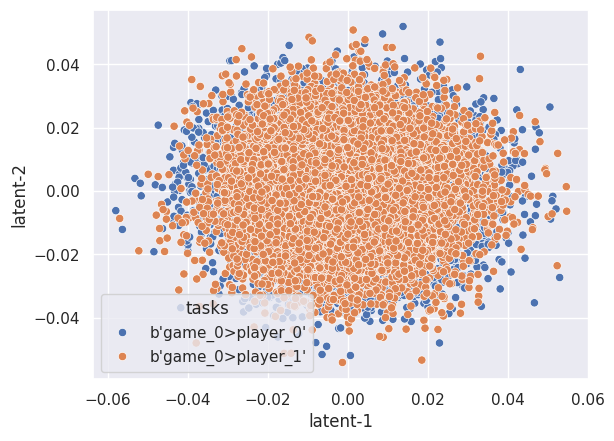

In [5]:
# Plotting the reduced dimensioned embeddings and tag based on the tasks (styles) 

embedding_data = []
for embedding, task in zip(np.array(embeddings), np.array(tasks)):
    embedding_data.append({'embeddings': embedding, 'tasks': task})
df = pandas.DataFrame(embedding_data)
df = df.fillna(0)


df_subset = df.drop('tasks', axis=1)

embeddings = np.array(embeddings)
df_fig = df.copy()
df_fig['latent-1'] = embeddings[:,0]
df_fig['latent-2'] = embeddings[:,1]
sns.scatterplot(
    x="latent-1", y="latent-2",
    # style="agent",
    hue="tasks",
    data=df_fig,
)

# tsne = TSNE(init='pca')
# tsne_results = tsne.fit_transform(np.array(embeddings))
# df_fig['tsne-2d-one'] = tsne_results[:,0]
# df_fig['tsne-2d-two'] = tsne_results[:,1]
# plt.figure(figsize=(16,10))
# sns.scatterplot(
#     x="tsne-2d-one", y="tsne-2d-two",
#     # style="agent",
#     hue="tasks",
#     data=df_fig,
# )

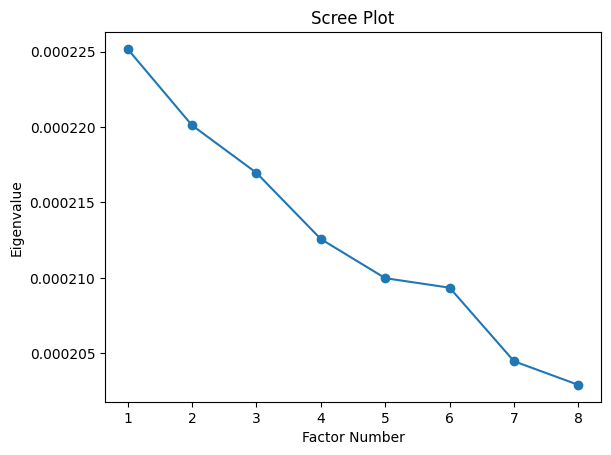

In [30]:
# Finding the best factor number for factor analysis
pca = PCA().fit(embeddings)
eigenvalues = pca.explained_variance_

# Find number of factors where eigenvalues > 1
# n_factors = np.sum(eigenvalues > 1)
# n_factors
import matplotlib.pyplot as plt

plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# n_factors = np.argmax(cumulative_variance >= 0.85) + 1
# n_factors


In [29]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42565 sha256=5f934ea1e3427cb541ae6f36bc7312be0a33c58f208d085e087c93c0a14149d6
  Stored in directory: /home/sara/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor-analyzer

[notice] A new release of pip is available: 23.3.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [32]:
from sklearn.decomposition import FactorAnalysis

n_factors = 2
fa = FactorAnalysis(n_components=n_factors)
factors = fa.fit_transform(X)
# Print the factor loadings

print("Factor Loadings:\n", fa.components_)

# Visualize the first two factors
plt.scatter(factors[:, 0], factors[:, 1])
plt.title('Factor Analysis: First Two Factors')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.show()

NameError: name 'X' is not defined

In [163]:
# ! pip install numpy --upgrade

## Embedding Dimension reduction

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

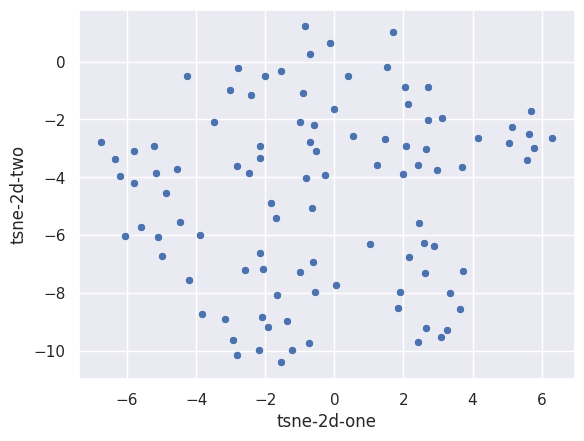

In [42]:
# projecting the skill embedding vectors to 2d dimension

# features = df.loc[:, :'petal_width']
# umap_2d = UMAP(n_components=2, n_neighbors=8, init='random', random_state=0)
# X = umap_2d.fit_transform(X)
# X = np.array(embeddings)
# X_tsne = TSNE(init='pca').fit_transform(X)
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
# plt.show()

# tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne = TSNE(init='pca')
tsne_results = tsne.fit_transform(X)
df_fig = df.copy()
df_fig['tsne-2d-one'] = tsne_results[:,0]
df_fig['tsne-2d-two'] = tsne_results[:,1]
# plt.figure(figsize=(16,10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    # style="agent",
    data=df_fig,
)

## Compute Clusters

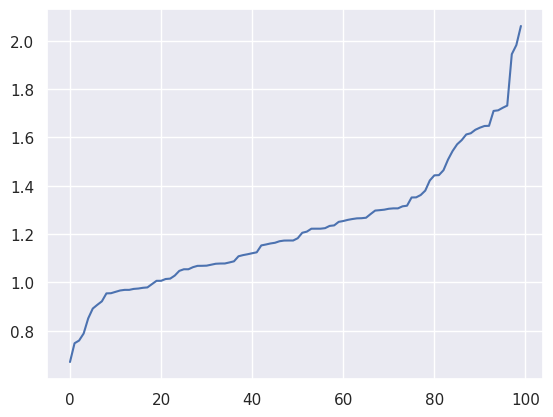

In [34]:
# trick to find the best value of epsilon for DBSCAN, the point of maximum curvature is the optimal epsilon
from sklearn.neighbors import NearestNeighbors
import numpy as np

# X_tsne = tsne_results
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_tsne)
distances, indices = neighbors_fit.kneighbors(X_tsne)
distances = np.sort(distances, axis=0)
# print(distances[:, 1])
distances = distances[:,-1]
plt.plot(distances)

In [46]:
# clustering of the embedding values

# X_tsne = tsne_results
db = KMeans(n_clusters=2).fit(X_tsne)
# db = DBSCAN(eps=1.6, min_samples=5).fit(X_tsne)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


## Plot results

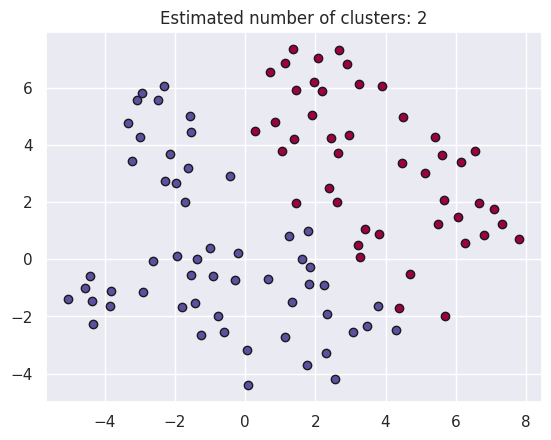

In [47]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
# core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_tsne[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_tsne[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()


## Analysing the clusters

In [48]:
df_fig = df.copy()
# df_fig['tsne-2d-one'] = X_tsne[:,0]
# df_fig['tsne-2d-two'] = X_tsne[:,1]
# df_fig['score'] = rewards
df_fig['clusters'] = labels
df_cluster = df_fig.sort_values('clusters')

# df_cluster = df_fig.query('`tsne-2d-one` > 1').query('`tsne-2d-two` > -2').sort_values('score')
# df_fig
df_cluster

,latent,action_0,action_1,action_2,action_3,action_4,action_5,clusters
49,"[tensor(-0.0088), tensor(-0.0036)]",0.285714,0.396104,0.055195,0.032468,0.198052,0.032468,0
75,"[tensor(-0.0145), tensor(-0.0144)]",0.202381,0.308201,0.121693,0.109788,0.205026,0.052910,0
33,"[tensor(-0.0009), tensor(0.0091)]",0.172269,0.267857,0.087185,0.075630,0.227941,0.169118,0
34,"[tensor(-0.0419), tensor(-0.0075)]",0.255291,0.247354,0.198413,0.079365,0.158730,0.060847,0
35,"[tensor(-0.0097), tensor(0.0204)]",0.189286,0.238095,0.128571,0.082143,0.211905,0.150000,0
...,...,...,...,...,...,...,...,...
31,"[tensor(0.0115), tensor(0.0149)]",0.278912,0.243197,0.086735,0.047619,0.311224,0.032313,1
30,"[tensor(-0.0022), tensor(-0.0018)]",0.240385,0.276099,0.144231,0.067308,0.157967,0.114011,1
29,"[tensor(-0.0028), tensor(-0.0263)]",0.353571,0.357143,0.092857,0.010714,0.139286,0.046429,1
25,"[tensor(0.0180), tensor(0.0230)]",0.121032,0.259921,0.103175,0.043651,0.351190,0.121032,1
